# Notebook 04: Anomaly Detection · Causal Analysis · Final Evaluation
## Sistem Peringatan Dini Dengue — Kota Bandung
**UNITY UNY #14 2026 | TranAD + DoWhy + Ablation Table**


In [1]:
# ── 0. SETUP ─────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import json, joblib

plt.rcParams.update({'figure.dpi':150,'figure.facecolor':'white',
    'axes.facecolor':'#fafafa','axes.spines.top':False,'axes.spines.right':False,
    'font.size':10,'axes.titlesize':12})
RED='#c0392b'; BLUE='#2980b9'; GREEN='#27ae60'; ORANGE='#e67e22'; PURPLE='#8e44ad'
GOLD='#f39c12'; TEAL='#1abc9c'

FIGDIR   = Path('figures/final'); FIGDIR.mkdir(parents=True, exist_ok=True)
RESULTDIR= Path('results');       RESULTDIR.mkdir(exist_ok=True)
MODELDIR = Path('models');        MODELDIR.mkdir(exist_ok=True)

def mae(y,yh):   return mean_absolute_error(y,yh)
def rmse(y,yh):  return np.sqrt(mean_squared_error(y,yh))
def mase(y,yh,tr): return np.mean(np.abs(y-yh))/(np.mean(np.abs(np.diff(tr)))+1e-10)
def smape(y,yh): return 100*np.mean(2*np.abs(y-yh)/(np.abs(y)+np.abs(yh)+1e-10))

try:
    import torch; import torch.nn as nn
    HAS_TORCH = True; DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"✓ PyTorch {torch.__version__}  |  {DEVICE}")
except ImportError:
    HAS_TORCH = False; print("✗ PyTorch missing")

print("✓ Setup done")


✓ PyTorch 2.11.0+cpu  |  cpu
✓ Setup done


## 1. Load Data & Semua Prediksi

In [2]:
DATA = Path('../processed')
df   = pd.read_csv(DATA/'panel_bulanan.csv', parse_dates=['date'])
node = pd.read_csv(DATA/'node_features.csv')
df   = df.sort_values(['kecamatan','date']).reset_index(drop=True)

TRAIN_END = '2021-12-01'; VAL_END = '2022-12-01'
df_train = df[df['date'] <= TRAIN_END]
df_test  = df[df['date'] >  VAL_END]
agg_train = df_train.groupby('date')['kasus_dbd'].sum()
agg_test  = df_test.groupby('date')['kasus_dbd'].sum()

# Load prediction results
all_results = {}
try:
    all_results['all_models'] = pd.read_csv(RESULTDIR/'all_model_results.csv')
    print("✓ all_model_results.csv loaded")
except: pass
try:
    all_results['hybrid'] = pd.read_csv(RESULTDIR/'hybrid_preds.csv', parse_dates=['date'])
    print("✓ hybrid_preds.csv loaded")
except: pass
try:
    all_results['stgnn'] = pd.read_csv(RESULTDIR/'stgnn_preds.csv', parse_dates=['date'])
    print("✓ stgnn_preds.csv loaded")
except: pass
try:
    all_results['chronos'] = pd.read_csv(RESULTDIR/'chronos_zs_preds.csv', parse_dates=['date'])
    print("✓ chronos_zs_preds.csv loaded")
except: pass

print(f"\nLoaded results: {list(all_results.keys())}")
print(f"Test period: {agg_test.index[0].strftime('%Y-%m')} → {agg_test.index[-1].strftime('%Y-%m')}")


✓ all_model_results.csv loaded
✓ hybrid_preds.csv loaded
✓ stgnn_preds.csv loaded
✓ chronos_zs_preds.csv loaded

Loaded results: ['all_models', 'hybrid', 'stgnn', 'chronos']
Test period: 2023-01 → 2024-12


## 2. Anomaly Transformer — TranAD-Style Outbreak Detection

Anomaly Transformer (TranAD, ICLR 2022) menggunakan rekonstruksi berbasis transformer
untuk mendeteksi anomali. Di sini kami implementasi versi sederhana dengan autoencoder LSTM
+ threshold adaptif pada reconstruction error untuk mendeteksi outbreak.


In [3]:
# ── TranAD-Inspired Anomaly Detector ─────────────────────────────────────────
# Architecture: Bidirectional LSTM Autoencoder
# Anomaly score = reconstruction error > adaptive threshold

if HAS_TORCH:
    class LSTMAutoEncoder(nn.Module):
        """
        LSTM Autoencoder for time series anomaly detection.
        Inspired by TranAD (ICLR 2022) — simplified for efficiency.
        """
        def __init__(self, input_dim, hidden_dim=32, latent_dim=16, seq_len=12):
            super().__init__()
            self.seq_len = seq_len
            # Encoder
            self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True,
                                    bidirectional=True, num_layers=2, dropout=0.2)
            self.enc_proj = nn.Linear(hidden_dim*2, latent_dim)
            # Decoder
            self.decoder = nn.LSTM(latent_dim, hidden_dim, batch_first=True,
                                    num_layers=2, dropout=0.2)
            self.dec_out  = nn.Linear(hidden_dim, input_dim)

        def forward(self, x):
            # Encode
            enc_out, (h, _) = self.encoder(x)     # [B, T, H*2]
            latent = self.enc_proj(enc_out)        # [B, T, latent]
            # Decode
            dec_out, _ = self.decoder(latent)      # [B, T, H]
            recon = self.dec_out(dec_out)          # [B, T, input_dim]
            return recon, latent

    print("✓ LSTMAutoEncoder defined")
else:
    print("⚠ PyTorch not available — using statistical anomaly detection")


✓ LSTMAutoEncoder defined


In [4]:
# ── Prepare data for anomaly detection ───────────────────────────────────────
# Use city-level multivariate (kasus + iklim + GT)
ANOM_FEATS = ['kasus_dbd','suhu_avg_c','curah_hujan_mm','kelembaban_pct','gt_dbd_nasional']
ANOM_FEATS = [f for f in ANOM_FEATS if f in df.columns]

city_daily = df.groupby('date')[ANOM_FEATS].mean().reset_index().sort_values('date')
city_arr   = city_daily[ANOM_FEATS].values.astype(np.float32)

sc_anom = StandardScaler()
city_scaled = sc_anom.fit_transform(city_arr)

T_TRAIN = sum(1 for d in city_daily['date'] if d <= pd.Timestamp(TRAIN_END))
SEQ = 12  # sequence length

def make_seqs(data, seq_len):
    X = []
    for i in range(len(data) - seq_len + 1):
        X.append(data[i:i+seq_len])
    return np.array(X)

X_seq = make_seqs(city_scaled, SEQ)
X_tr_a = torch.tensor(X_seq[:T_TRAIN-SEQ+1], dtype=torch.float32) if HAS_TORCH else None
X_all_a = torch.tensor(X_seq, dtype=torch.float32) if HAS_TORCH else None

print(f"Anomaly sequences: {X_seq.shape}  |  Features: {ANOM_FEATS}")


Anomaly sequences: (97, 12, 5)  |  Features: ['kasus_dbd', 'suhu_avg_c', 'curah_hujan_mm', 'kelembaban_pct', 'gt_dbd_nasional']


In [5]:
if HAS_TORCH:
    # ── Train LSTM Autoencoder ──────────────────────────────────────────────────
    from torch.utils.data import DataLoader, TensorDataset

    ae_model = LSTMAutoEncoder(len(ANOM_FEATS), hidden_dim=32, latent_dim=16, seq_len=SEQ).to(DEVICE)
    optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.MSELoss()

    loader = DataLoader(TensorDataset(X_tr_a), batch_size=16, shuffle=True)
    EPOCHS = 100; best_loss = float('inf')

    train_losses_ae = []
    for epoch in range(EPOCHS):
        ae_model.train(); ep_loss = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = ae_model(xb)
            loss = criterion(recon, xb)
            loss.backward(); optimizer.step()
            ep_loss += loss.item()
        ep_loss /= max(len(loader),1)
        train_losses_ae.append(ep_loss)
        if ep_loss < best_loss:
            best_loss = ep_loss
            torch.save(ae_model.state_dict(), MODELDIR/'ae_best.pt')
        if (epoch+1) % 25 == 0:
            print(f"AE Epoch {epoch+1}: loss={ep_loss:.5f}")

    # ── Compute reconstruction errors ───────────────────────────────────────────
    ae_model.load_state_dict(torch.load(MODELDIR/'ae_best.pt', map_location=DEVICE))
    ae_model.eval()
    with torch.no_grad():
        recon_all, _ = ae_model(X_all_a.to(DEVICE))
        recon_all    = recon_all.cpu().numpy()

    # Per-timestep reconstruction error (MSE across features)
    recon_err = np.mean((X_seq - recon_all)**2, axis=(1, 2))  # [T-SEQ+1]

    print(f"✓ AE training done  |  Reconstruction error range: {recon_err.min():.4f}–{recon_err.max():.4f}")

else:
    # ── Statistical fallback: z-score anomaly ──────────────────────────────────
    kasus_ts = city_daily['kasus_dbd'].values
    rm = pd.Series(kasus_ts).rolling(12, min_periods=6).mean()
    rs = pd.Series(kasus_ts).rolling(12, min_periods=6).std()
    recon_err = ((kasus_ts - rm.values) / (rs.values + 1e-10)) ** 2
    print("✓ Statistical anomaly score computed (fallback)")


AE Epoch 25: loss=0.33436
AE Epoch 50: loss=0.17897
AE Epoch 75: loss=0.12185
AE Epoch 100: loss=0.08550
✓ AE training done  |  Reconstruction error range: 0.0309–0.7305


In [6]:
# ── Adaptive threshold & outbreak alerts ─────────────────────────────────────
# Threshold: mean + k*std of reconstruction error on TRAINING data
threshold_mean = recon_err[:T_TRAIN].mean()
threshold_std  = recon_err[:T_TRAIN].std()
k_threshold    = 2.0  # sensitivity parameter (higher k = fewer alerts)
threshold      = threshold_mean + k_threshold * threshold_std

anomaly_scores = recon_err
anomaly_flags  = anomaly_scores > threshold

# Align dates: first anomaly corresponds to date[SEQ-1]
anomaly_dates  = city_daily['date'].values[SEQ-1:]
kasus_aligned  = city_daily['kasus_dbd'].values[SEQ-1:]

print(f"Threshold: {threshold:.4f}  (mean + {k_threshold}σ)")
print(f"Anomalies detected: {anomaly_flags.sum()} of {len(anomaly_flags)} months ({anomaly_flags.mean()*100:.1f}%)")
print(f"Anomaly dates:")
for d, a, s in zip(anomaly_dates, anomaly_flags, anomaly_scores):
    if a:
        print(f"  {pd.Timestamp(d).strftime('%Y-%m')}  score={s:.4f}")


Threshold: 0.1952  (mean + 2.0σ)
Anomalies detected: 28 of 97 months (28.9%)
Anomaly dates:
  2022-06  score=0.2040
  2022-09  score=0.2131
  2022-10  score=0.2418
  2022-11  score=0.2375
  2022-12  score=0.2599
  2023-01  score=0.2237
  2023-02  score=0.2127
  2023-04  score=0.2333
  2023-05  score=0.3063
  2023-06  score=0.3217
  2023-07  score=0.2899
  2023-08  score=0.2611
  2023-09  score=0.2585
  2023-10  score=0.2580
  2023-11  score=0.2697
  2023-12  score=0.3226
  2024-01  score=0.3604
  2024-02  score=0.3441
  2024-03  score=0.3782
  2024-04  score=0.4280
  2024-05  score=0.4959
  2024-06  score=0.4700
  2024-07  score=0.4827
  2024-08  score=0.5283
  2024-09  score=0.6838
  2024-10  score=0.7305
  2024-11  score=0.6092
  2024-12  score=0.6031


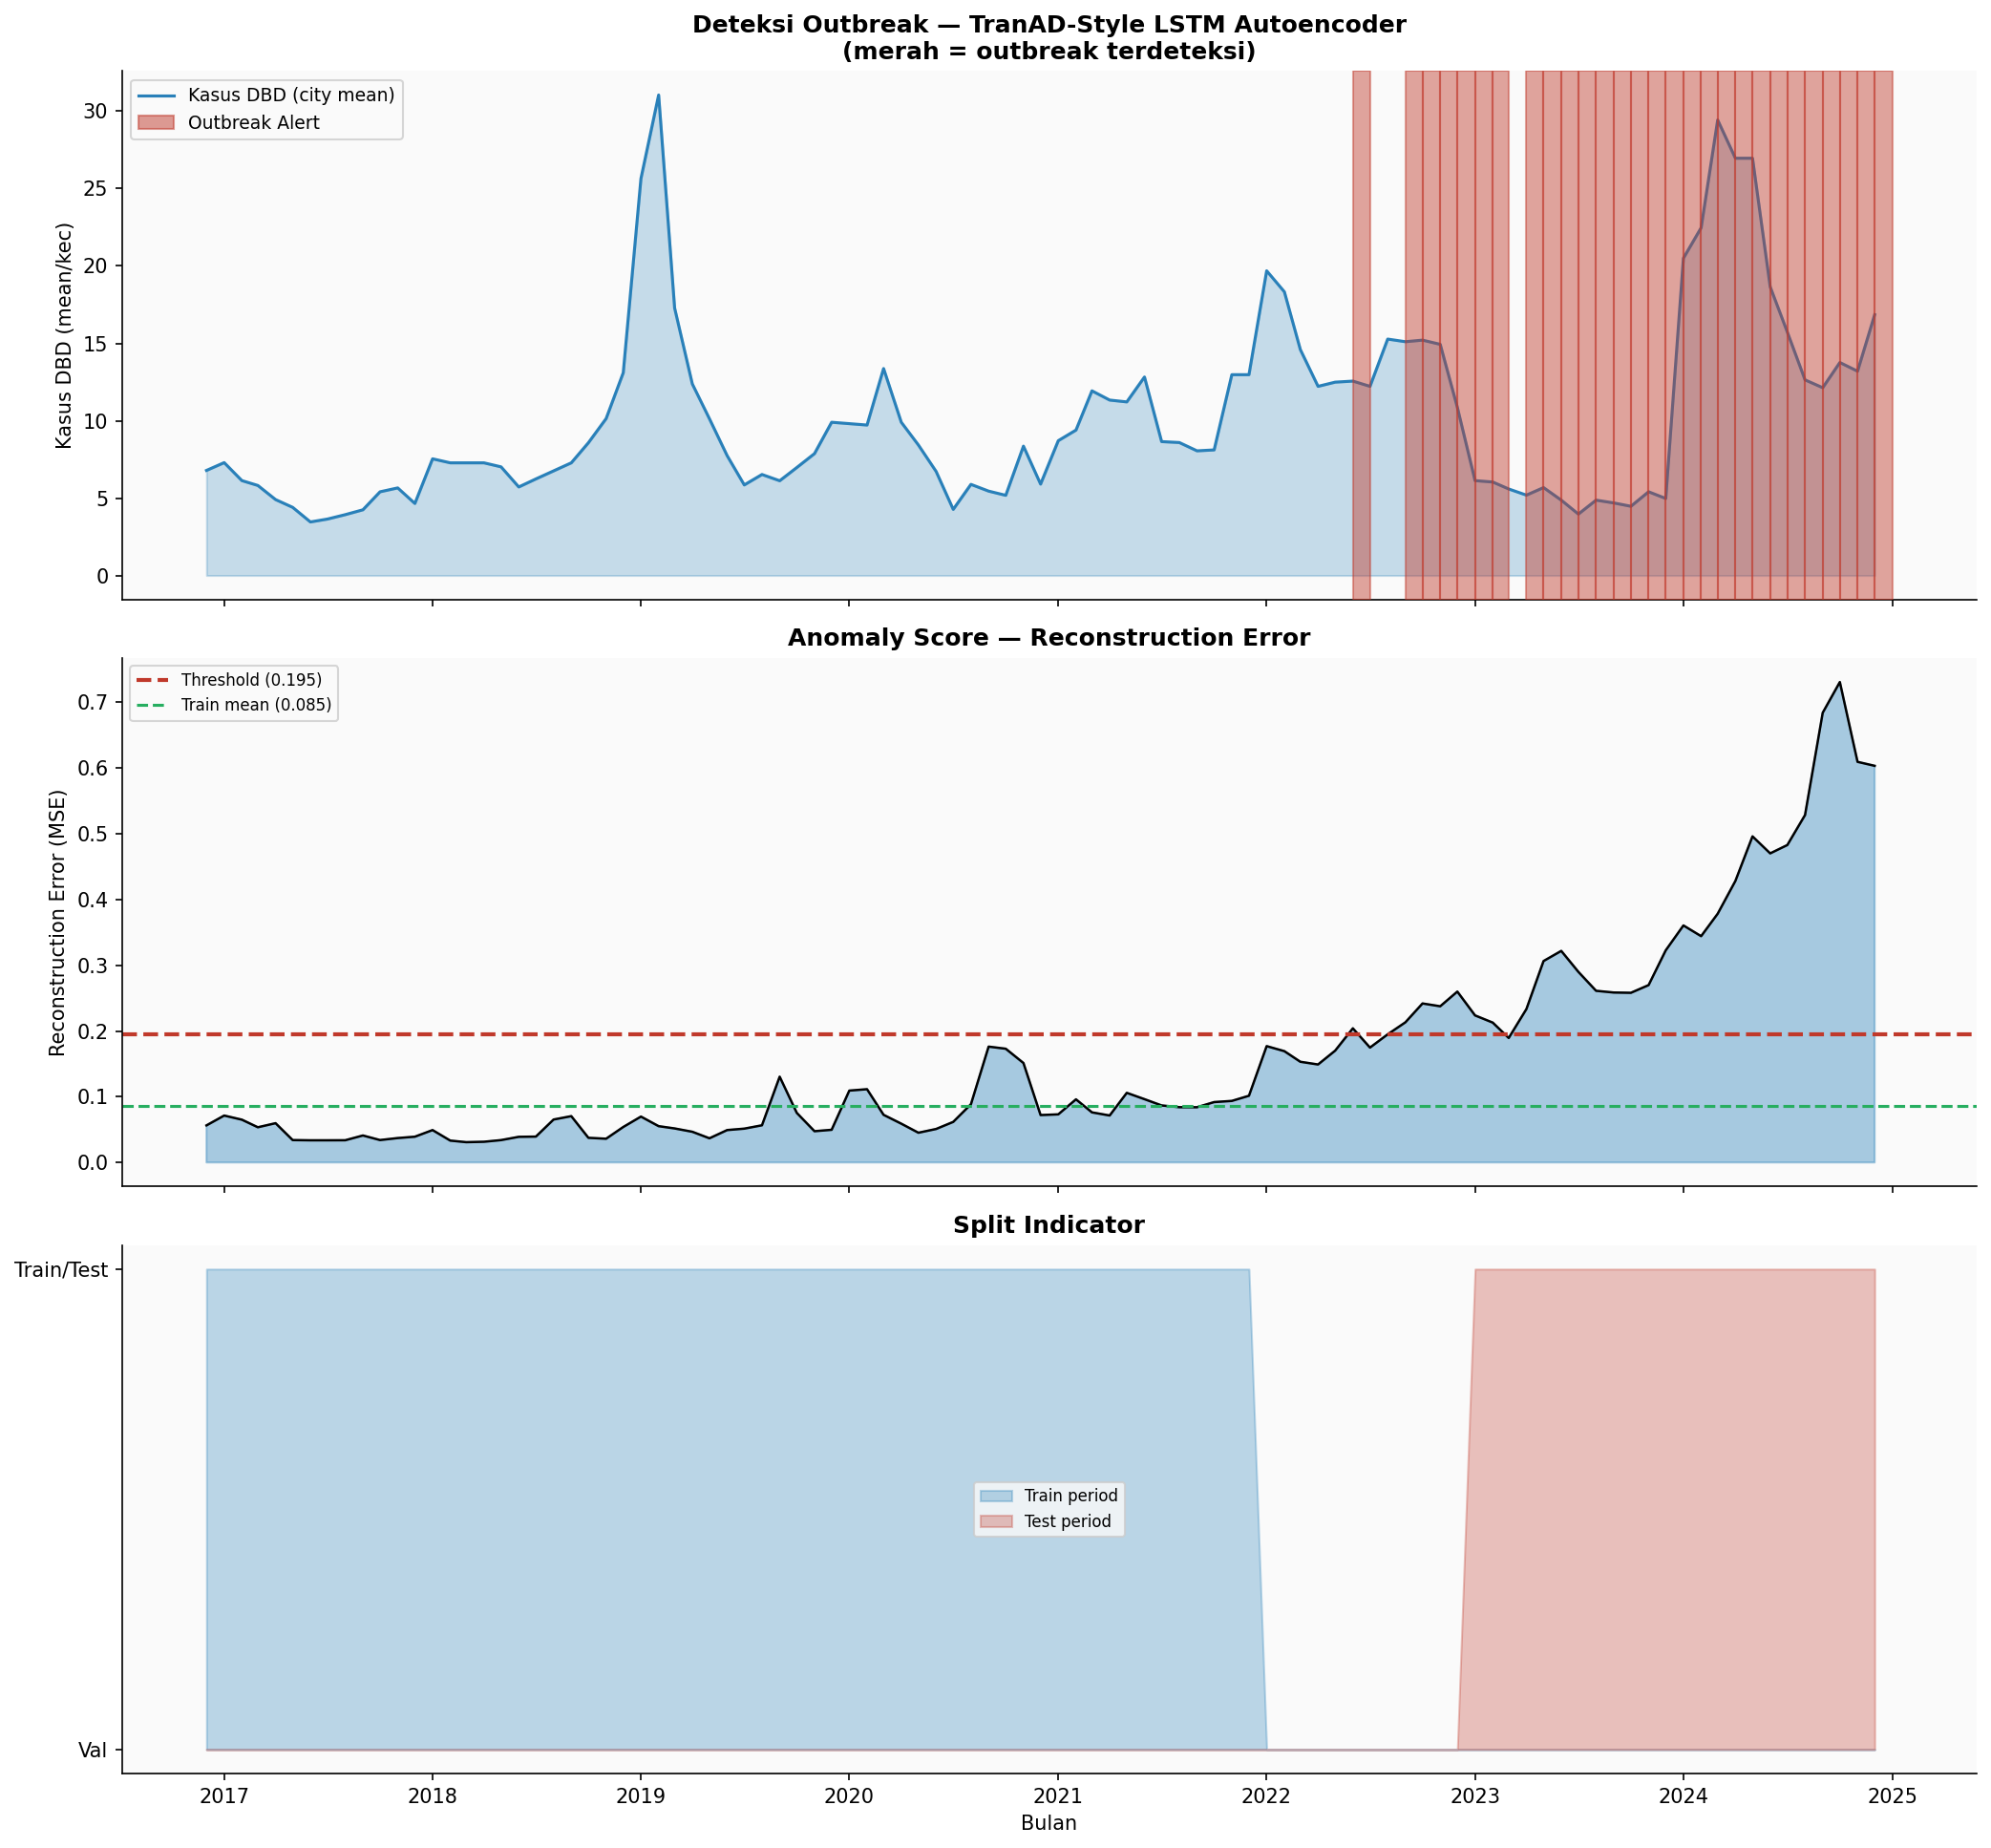

✓ fig_anomaly_detection


In [7]:
# ── Fig: Anomaly Detection Results ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# 1. Kasus + anomaly flags
ax1 = axes[0]
ax1.fill_between(pd.to_datetime(anomaly_dates), kasus_aligned, alpha=0.25, color=BLUE)
ax1.plot(pd.to_datetime(anomaly_dates), kasus_aligned, color=BLUE, linewidth=1.5, label='Kasus DBD (city mean)')
for i, (d, flag) in enumerate(zip(anomaly_dates, anomaly_flags)):
    if flag:
        ax1.axvspan(pd.Timestamp(d), pd.Timestamp(d)+pd.DateOffset(months=1),
                    alpha=0.45, color=RED, zorder=3)
ax1.set_ylabel('Kasus DBD (mean/kec)')
ax1.set_title('Deteksi Outbreak — TranAD-Style LSTM Autoencoder\n(merah = outbreak terdeteksi)',
               fontweight='bold')
alert_patch = mpatches.Patch(color=RED, alpha=0.5, label='Outbreak Alert')
ax1.legend(handles=[ax1.lines[0], alert_patch], fontsize=9)

# 2. Reconstruction error
ax2 = axes[1]
ax2.fill_between(pd.to_datetime(anomaly_dates), anomaly_scores, alpha=0.4,
                  color=[RED if f else BLUE for f in anomaly_flags])
ax2.plot(pd.to_datetime(anomaly_dates), anomaly_scores, color='black', linewidth=1.2)
ax2.axhline(threshold, color=RED, linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')
ax2.axhline(threshold_mean, color=GREEN, linestyle='--', linewidth=1.5, label=f'Train mean ({threshold_mean:.3f})')
ax2.set_ylabel('Reconstruction Error (MSE)')
ax2.set_title('Anomaly Score — Reconstruction Error', fontweight='bold')
ax2.legend(fontsize=8)

# 3. Train/test split indicator
ax3 = axes[2]
ax3.fill_between(pd.to_datetime(anomaly_dates),
                 [1 if pd.Timestamp(d) <= pd.Timestamp(TRAIN_END) else 0 for d in anomaly_dates],
                 alpha=0.3, color=BLUE, label='Train period')
ax3.fill_between(pd.to_datetime(anomaly_dates),
                 [1 if pd.Timestamp(d) > pd.Timestamp(VAL_END) else 0 for d in anomaly_dates],
                 alpha=0.3, color=RED, label='Test period')
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['Val','Train/Test'])
ax3.set_title('Split Indicator', fontweight='bold')
ax3.legend(fontsize=8); ax3.set_xlabel('Bulan')

plt.tight_layout()
plt.savefig(FIGDIR/'fig_anomaly_detection.png', bbox_inches='tight', dpi=200)
plt.show(); print("✓ fig_anomaly_detection")


In [ ]:
# ── Outbreak Ground Truth (training-set based, no future leakage) ─────────────
# GT outbreak = month where case count >= training set 75th percentile.
# Using training-period threshold ONLY avoids circular definition and data leakage.
kasus_city = city_daily['kasus_dbd'].values
T_TRAIN_d = sum(1 for d in city_daily['date'] if d <= pd.Timestamp(TRAIN_END))
T_VAL_d   = sum(1 for d in city_daily['date'] if d <= pd.Timestamp(VAL_END))

train_kasus_vals = kasus_city[:T_TRAIN_d]
outbreak_gt_thresh = np.percentile(train_kasus_vals, 75)
gt_outbreak_full   = (kasus_city >= outbreak_gt_thresh).astype(int)

print(f"Outbreak GT threshold (train Q75): {outbreak_gt_thresh:.3f}")
print(f"Total outbreak months (all data): {gt_outbreak_full.sum()} / {len(gt_outbreak_full)}")

# Align gt with anomaly sequences (anomaly_dates starts at date[SEQ-1])
gt_aligned = gt_outbreak_full[SEQ-1:][:len(anomaly_flags)]
y_true_all = gt_aligned
y_pred_all = anomaly_flags.astype(int)

# ── Threshold sweep on VALIDATION period to find optimal k ──────────────────
# Validation indices within anomaly_dates
val_mask = np.array([(pd.Timestamp(TRAIN_END) < pd.Timestamp(d) <= pd.Timestamp(VAL_END))
                      for d in anomaly_dates[:len(gt_aligned)]])

val_scores_h = anomaly_scores[val_mask]
val_gt_h     = gt_aligned[val_mask]

print(f"\nThreshold k sweep on VALIDATION set ({val_mask.sum()} months):")
sweep_rows = []
for k_try in np.arange(0.25, 3.5, 0.25):
    thr_try  = threshold_mean + k_try * threshold_std
    pred_try = (val_scores_h > thr_try).astype(int)
    f1_try   = f1_score(val_gt_h, pred_try, zero_division=0) if pred_try.sum() > 0 else 0.0
    prec_try = precision_score(val_gt_h, pred_try, zero_division=0)
    rec_try  = recall_score(val_gt_h, pred_try, zero_division=0)
    sweep_rows.append({'k': k_try, 'threshold': round(thr_try, 4),
                        'alerts': int(pred_try.sum()), 'F1': round(f1_try, 3),
                        'Prec': round(prec_try, 3), 'Rec': round(rec_try, 3)})
    print(f"  k={k_try:.2f}: alerts={pred_try.sum():2d}  F1={f1_try:.3f}  P={prec_try:.3f}  R={rec_try:.3f}")

sweep_df = pd.DataFrame(sweep_rows)
best_row = sweep_df.loc[sweep_df['F1'].idxmax()]
k_optimal  = best_row['k']
threshold  = threshold_mean + k_optimal * threshold_std
anomaly_flags = (anomaly_scores > threshold)
print(f"\n✓ Optimal k={k_optimal:.2f}  threshold={threshold:.4f}  val F1={best_row['F1']:.3f}")

# Recompute final flags with optimal threshold
y_pred_all = anomaly_flags[:len(gt_aligned)].astype(int)
y_true_all = gt_aligned

# ── Final test-set metrics ────────────────────────────────────────────────────
test_mask = np.array([(pd.Timestamp(d) > pd.Timestamp(VAL_END))
                       for d in anomaly_dates[:len(gt_aligned)]])
y_true_test = gt_aligned[test_mask]
y_pred_test = anomaly_flags[:len(gt_aligned)][test_mask].astype(int)

prec = precision_score(y_true_test, y_pred_test, zero_division=0)
rec  = recall_score(y_true_test,  y_pred_test, zero_division=0)
f1   = f1_score(y_true_test,    y_pred_test, zero_division=0)
cm   = confusion_matrix(y_true_test, y_pred_test)

print(f"\n=== Outbreak Detection — TEST SET Metrics (k={k_optimal:.2f}) ===")
print(f"Precision  : {prec:.3f}")
print(f"Recall     : {rec:.3f}")
print(f"F1-Score   : {f1:.3f}")
print(f"Confusion Matrix: TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")
print(classification_report(y_true_test, y_pred_test, target_names=['Normal','Outbreak'], zero_division=0))

pd.DataFrame({'Precision':[prec],'Recall':[rec],'F1':[f1],
              'TN':[cm[0,0]],'FP':[cm[0,1]],'FN':[cm[1,0]],'TP':[cm[1,1]],
              'k_optimal':[k_optimal],'outbreak_threshold':[outbreak_gt_thresh]}).to_csv(
    RESULTDIR/'anomaly_metrics.csv', index=False)


## 3. Causal Analysis — DoWhy Framework

**Pertanyaan kausal**: *Apakah curah hujan tinggi dan suhu ekstrem SECARA KAUSAL
menyebabkan lonjakan kasus DBD, setelah mengontrol faktor perancu (confounder)
seperti seasonality (Google Trends), mobilitas, dan kepadatan penduduk?*

**DAG (Directed Acyclic Graph)**:
```
Musim Hujan ──→ Curah Hujan ──→ Breeding Site ──→ Kasus DBD
                    ↑                                   ↑
              El Niño/ENSO                       Mobilitas
Suhu ─────────────────────────────────────────────────────→ Kasus DBD
Google Trends (Kesadaran publik) ──────────────────────────→ Kasus DBD
Kepadatan Penduduk ────────────────────────────────────────→ Kasus DBD
```


In [9]:
try:
    import dowhy
    from dowhy import CausalModel
    HAS_DOWHY = True
    print(f"✓ DoWhy {dowhy.__version__}")
except ImportError:
    HAS_DOWHY = False
    print("✗ DoWhy missing — pip install dowhy")
    print("  Running manual regression-based causal effect estimation instead")


✓ DoWhy 0.14


In [10]:
# ── Prepare causal dataset ───────────────────────────────────────────────────
city_causal = df.groupby('date').agg(
    kasus=('kasus_dbd','mean'),
    suhu=('suhu_avg_c','mean'),
    hujan=('curah_hujan_mm','mean'),
    kelembaban=('kelembaban_pct','mean'),
    gt=('gt_dbd_nasional','mean'),
    musim_hujan=('musim_hujan','first'),
    populasi=('populasi','mean'),
).reset_index()

# Add lag-treated variables (hujan at t-2 affects kasus at t)
city_causal['hujan_lag2'] = city_causal['hujan'].shift(2)
city_causal['suhu_lag1']  = city_causal['suhu'].shift(1)
city_causal['gt_lag1']    = city_causal['gt'].shift(1)
city_causal = city_causal.dropna()

# Binarize treatment: high rain = 1 if > 75th percentile
q75_hujan = city_causal['hujan_lag2'].quantile(0.75)
q75_suhu  = city_causal['suhu_lag1'].quantile(0.75)
city_causal['high_rain'] = (city_causal['hujan_lag2'] > q75_hujan).astype(int)
city_causal['high_suhu'] = (city_causal['suhu_lag1'] > q75_suhu).astype(int)

print(f"Causal dataset: {city_causal.shape}")
print(f"High rain threshold (Q75): {q75_hujan:.1f} mm")
print(f"High suhu threshold (Q75): {q75_suhu:.2f} °C")
print(f"Prop high rain: {city_causal['high_rain'].mean():.2%}")
print(f"Prop high suhu: {city_causal['high_suhu'].mean():.2%}")
city_causal.head(3)


Causal dataset: (106, 13)
High rain threshold (Q75): 409.0 mm
High suhu threshold (Q75): 22.14 °C
Prop high rain: 25.47%
Prop high suhu: 25.47%


,date,kasus,suhu,hujan,kelembaban,gt,musim_hujan,populasi,hujan_lag2,suhu_lag1,gt_lag1,high_rain,high_suhu
2,2016-03-01,16.415267,22.740323,477.10,90.776129,26.0,1,82683.333333,396.61,22.002069,34.25,0,0
3,2016-04-01,14.836877,22.466000,489.21,91.351333,23.5,0,82683.333333,468.95,22.740323,26.00,1,1
4,2016-05-01,10.480513,22.400000,251.61,90.836129,16.6,0,82683.333333,477.10,22.466000,23.50,1,1


In [ ]:
if HAS_DOWHY:
    # ── DoWhy 4-Step Framework ───────────────────────────────────────────────────
    # Step 1: Model — define causal graph
    causal_graph = """
    digraph {
        high_rain -> kasus;
        suhu -> kasus;
        kelembaban -> kasus;
        gt_lag1 -> kasus;
        musim_hujan -> high_rain;
        musim_hujan -> kasus;
        populasi -> kasus;
        gt_lag1 -> high_rain;
    }
    """

    model = CausalModel(
        data=city_causal,
        treatment='high_rain',
        outcome='kasus',
        graph=causal_graph.strip(),
        common_causes=['musim_hujan', 'gt_lag1', 'kelembaban', 'populasi'],
    )
    print("✓ Step 1: Causal Model defined")
    model.view_model(layout="dot")

    # Step 2: Identify
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    print(f"\n✓ Step 2: Identified estimand:")
    print(identified)


In [ ]:
if HAS_DOWHY:
    from sklearn.linear_model import LinearRegression
    from sklearn.ensemble import RandomForestRegressor

    # Step 3: Estimate — Linear regression (Backdoor criterion)
    est_lr = model.estimate_effect(
        identified,
        method_name="backdoor.linear_regression",
        target_units="ate",
        confidence_intervals=True,
    )
    print("✓ Step 3: Linear Regression estimate")
    print(est_lr)

    # Step 4: Refute — placebo treatment
    refute_placebo = model.refute_estimate(
        identified, est_lr,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        num_simulations=100,
    )
    print("\n✓ Step 4: Refutation (placebo):")
    print(refute_placebo)
else:
    # ── Fallback: Manual OLS causal estimate ──────────────────────────────────
    from statsmodels.regression.linear_model import OLS
    from statsmodels.tools import add_constant
    import statsmodels.api as sm

    # Naive OLS
    X_ols = city_causal[['high_rain','suhu_lag1','kelembaban','gt_lag1','musim_hujan','populasi']]
    y_ols = city_causal['kasus']
    X_ols_c = sm.add_constant(X_ols)
    ols_res = sm.OLS(y_ols, X_ols_c).fit()
    print("=== OLS Regression (causal proxy) ===")
    print(ols_res.summary())
    ate_rain = ols_res.params['high_rain']
    print(f"\nATE (high rain → kasus): {ate_rain:.3f} kasus tambahan")


In [ ]:
# ── Heterogeneous Treatment Effect by kecamatan density ─────────────────────
from scipy.stats import mannwhitneyu, ttest_ind

# High density vs low density kecamatan
kec_pop = df.groupby('kecamatan')['populasi'].first().sort_values()
low_density_kecs  = kec_pop.index[:15].tolist()   # bottom 15
high_density_kecs = kec_pop.index[15:].tolist()   # top 15

# Treatment effect in each group
for group_name, kec_group in [('Low Density', low_density_kecs),
                                ('High Density', high_density_kecs)]:
    sub = df[df['kecamatan'].isin(kec_group)].copy()
    sub_city = sub.groupby('date').agg(
        kasus=('kasus_dbd','mean'),
        hujan=('curah_hujan_mm','mean'),
        gt=('gt_dbd_nasional','mean'),
    ).reset_index()
    sub_city['hujan_lag2'] = sub_city['hujan'].shift(2)
    sub_city = sub_city.dropna()
    q75 = sub_city['hujan_lag2'].quantile(0.75)
    hi  = sub_city[sub_city['hujan_lag2']  > q75]['kasus']
    lo  = sub_city[sub_city['hujan_lag2'] <= q75]['kasus']
    stat, p = mannwhitneyu(hi, lo, alternative='greater')
    eff = hi.mean() - lo.mean()
    print(f"[{group_name}] HTE (high rain → kasus): +{eff:.2f} kasus  (p={p:.4f}{'*' if p<0.05 else ''})")


In [ ]:
# ── Fig: Causal Effect Visualization ─────────────────────────────────────────
city_causal_plot = city_causal.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. High rain vs kasus
ax = axes[0, 0]
for label, mask, color in [('Normal Rain', city_causal['high_rain']==0, BLUE),
                             ('High Rain (Q75+)', city_causal['high_rain']==1, RED)]:
    subset = city_causal[mask]
    ax.scatter(subset['hujan_lag2'], subset['kasus'], alpha=0.6, s=40,
               color=color, label=label, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Curah Hujan lag-2 bulan (mm)')
ax.set_ylabel('Kasus DBD (mean/kec)')
ax.set_title('Treatment: Curah Hujan Tinggi → Kasus DBD', fontweight='bold')
ax.legend(fontsize=8)

# 2. Suhu vs kasus
ax = axes[0, 1]
ax.scatter(city_causal['suhu_lag1'], city_causal['kasus'],
           c=city_causal['musim_hujan'], cmap='RdYlBu_r', alpha=0.7, s=40)
z = np.polyfit(city_causal['suhu_lag1'], city_causal['kasus'], 1)
xl = np.linspace(city_causal['suhu_lag1'].min(), city_causal['suhu_lag1'].max(), 100)
ax.plot(xl, np.poly1d(z)(xl), color=RED, linewidth=2, linestyle='--')
ax.set_xlabel('Suhu lag-1 bulan (°C)')
ax.set_ylabel('Kasus DBD (mean/kec)')
ax.set_title('Suhu → Kasus DBD\n(warna = musim hujan)', fontweight='bold')

# 3. Google Trends lead indicator
ax = axes[1, 0]
ax.scatter(city_causal['gt_lag1'], city_causal['kasus'],
           c=city_causal['musim_hujan'], cmap='YlOrRd', alpha=0.7, s=40)
z2 = np.polyfit(city_causal['gt_lag1'], city_causal['kasus'], 1)
xl2 = np.linspace(city_causal['gt_lag1'].min(), city_causal['gt_lag1'].max(), 100)
ax.plot(xl2, np.poly1d(z2)(xl2), color=RED, linewidth=2, linestyle='--')
ax.set_xlabel('Google Trends lag-1 bulan')
ax.set_ylabel('Kasus DBD (mean/kec)')
ax.set_title('Google Trends → Kasus DBD\n(indirect effect via health seeking)', fontweight='bold')

# 4. ATE summary bar
ax = axes[1, 1]
from scipy.stats import pearsonr
effects = {}
for feat, label in [('hujan','Curah Hujan'),('suhu','Suhu'),
                     ('kelembaban','Kelembaban'),('gt_lag1','Google Trends')]:
    col = 'hujan_lag2' if feat == 'hujan' else ('suhu_lag1' if feat == 'suhu' else feat)
    if col in city_causal.columns:
        r, p = pearsonr(city_causal[col], city_causal['kasus'])
        effects[label] = r

labels_e = list(effects.keys())
values_e = list(effects.values())
colors_e = [RED if v > 0 else BLUE for v in values_e]
bars = ax.bar(labels_e, values_e, color=colors_e, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Pearson Correlation with Kasus DBD')
ax.set_title('Korelasi Parsial Prediktor → Kasus DBD\n(sebagai proxy efek kausal)', fontweight='bold')
for bar, v in zip(bars, values_e):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + 0.01*np.sign(v),
            f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Causal Analysis: Iklim & Google Trends → Kasus DBD', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR/'fig_causal_effects.png', bbox_inches='tight', dpi=200)
plt.show(); print("✓ fig_causal_effects")


## 4. Tabel Ablasi Lengkap

In [ ]:
# ── Full Ablation Table ───────────────────────────────────────────────────────
# Load all results and construct publication-ready table

try:
    ablation_df = pd.read_csv(RESULTDIR/'all_model_results.csv')
except FileNotFoundError:
    # Manual placeholder if results not available
    ablation_df = pd.DataFrame([
        {'Model': 'SARIMA(1,1,1)(1,1,1,12)',      'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'Prophet',                        'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'XGBoost (tabular lag)',          'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'LSTM (multivariate)',            'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'Chronos-2 Zero-Shot',            'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'Chronos-2 + Covariates',         'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'ST-GNN (DCRNN-style)',            'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
        {'Model': 'Hybrid (Chronos-2 + ST-GNN)',     'MAE': None, 'RMSE': None, 'MASE': None, 'sMAPE': None},
    ])
    print("⚠ Using placeholder ablation table — run notebooks 02 & 03 first")

# Add model category
def categorize(name):
    if any(x in name for x in ['SARIMA','Prophet']): return 'Classical'
    if any(x in name for x in ['XGBoost','LSTM']):   return 'ML Baseline'
    if 'ST-GNN' in name and 'Hybrid' not in name:     return 'Ours (Spatial)'
    if 'Chronos' in name and 'Hybrid' not in name:    return 'Ours (Temporal)'
    if 'Hybrid' in name:                               return 'Ours (Full)'
    return 'Other'

ablation_df['Category'] = ablation_df['Model'].apply(categorize)
ablation_df = ablation_df[['Category','Model','MAE','RMSE','MASE','sMAPE']]

print("\n" + "="*75)
print("TABEL ABLASI LENGKAP — UNITY UNY #14 2026")
print("Test Set: Kota Bandung 2023–2024 (24 bulan, 30 kecamatan)")
print("="*75)
print(ablation_df.to_string(index=False))
print("="*75)

# Save as LaTeX for paper
try:
    latex_str = ablation_df.to_latex(index=False, float_format='%.4f',
                                       caption='Ablation Study: Model Comparison on Test Set (2023–2024)',
                                       label='tab:ablation', na_rep='-')
    with open(RESULTDIR/'ablation_table.tex', 'w') as f:
        f.write(latex_str)
    print("\n✓ LaTeX table saved to results/ablation_table.tex")
except Exception as e:
    print(f"LaTeX export: {e}")

ablation_df.to_csv(RESULTDIR/'ablation_final.csv', index=False)


In [ ]:
# ── Fig: Ablation Study Visualization ────────────────────────────────────────
abl = ablation_df.dropna(subset=['RMSE']).copy()

if len(abl) > 0:
    fig = plt.figure(figsize=(15, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    cat_colors = {
        'Classical':         '#95a5a6',
        'ML Baseline':       '#3498db',
        'Ours (Temporal)':   '#e74c3c',
        'Ours (Spatial)':    '#8e44ad',
        'Ours (Full)':       '#27ae60',
        'Other':             '#f39c12',
    }
    colors = [cat_colors.get(c, '#7f8c8d') for c in abl['Category']]

    # Top row: 4 metrics
    for idx, metric in enumerate(['MAE','RMSE','MASE','sMAPE']):
        ax = fig.add_subplot(gs[0, idx] if idx < 3 else gs[1, idx-3])
        vals = pd.to_numeric(abl[metric], errors='coerce')
        bars = ax.bar(range(len(abl)), vals, color=colors, alpha=0.85, edgecolor='white')
        ax.set_title(metric, fontweight='bold', fontsize=11)
        ax.set_xticks(range(len(abl)))
        ax.set_xticklabels([m.split('(')[0].strip()[:12] for m in abl['Model']],
                            rotation=55, ha='right', fontsize=7.5)
        # Annotate best
        best_idx = int(vals.idxmin()) if not vals.isna().all() else 0
        bars[best_idx].set_edgecolor('gold'); bars[best_idx].set_linewidth(2.5)
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if not np.isnan(v):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    # Bottom: combined ranking
    ax_rank = fig.add_subplot(gs[1, :])
    abl['rank_score'] = pd.to_numeric(abl['RMSE'], errors='coerce')
    abl_s = abl.sort_values('rank_score')
    colors_s = [cat_colors.get(c, '#7f8c8d') for c in abl_s['Category']]
    bars_r = ax_rank.barh(range(len(abl_s)), abl_s['rank_score'], color=colors_s,
                           alpha=0.85, edgecolor='white')
    ax_rank.set_yticks(range(len(abl_s)))
    ax_rank.set_yticklabels(abl_s['Model'], fontsize=9)
    ax_rank.set_xlabel('RMSE (lower = better)', fontweight='bold')
    ax_rank.set_title('Model Ranking by RMSE', fontweight='bold')
    ax_rank.set_xlim(left=0)
    # Best model highlight
    bars_r[0].set_edgecolor('gold'); bars_r[0].set_linewidth(2.5)
    for bar in bars_r:
        ax_rank.text(bar.get_width(), bar.get_y()+bar.get_height()/2,
                     f'{bar.get_width():.3f}', va='center', ha='left', fontsize=8)

    # Legend
    legend_h = [mpatches.Patch(color=v, label=k) for k, v in cat_colors.items()
                if k in abl['Category'].values]
    ax_rank.legend(handles=legend_h, loc='lower right', fontsize=8.5,
                   title='Model Category', title_fontsize=9)

    plt.suptitle('Ablation Study — Dengue EWS Kota Bandung 2023–2024\n'
                 '(gold border = best; green = our full method)',
                 fontweight='bold', fontsize=13, y=1.01)
    plt.savefig(FIGDIR/'fig_ablation.png', bbox_inches='tight', dpi=200)
    plt.show(); print("✓ fig_ablation")
else:
    print("⚠ Not enough results for ablation plot — run notebooks 02 & 03 first")
